# Automating NGO Donation Analysis with Functions & Streamlit

## Real-World Scenario

**Organization:** Food Bank USA (hypothetical NGO)  
**Problem:** Process monthly donation records, calculate impact metrics, and generate donor reports manually - same tasks repeated every month, prone to errors, time-consuming.

**Solution:** Build reusable functions + pipeline + Streamlit app to automate the entire process.

## What We'll Build

A tool that automatically:
- ✓ Cleans donation data (dates, amounts, categories)
- ✓ Calculates key metrics (total donations, donor retention, average gift)
- ✓ Generates impact summaries (meals served, neighborhoods reached)
- ✓ Creates visualizations for donor reports
- ✓ Exports results to CSV

**Result:** What takes 2 hours manually → 30 seconds automated

## Part 1: Create Reusable Functions for Donation Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [4]:

# Function 1: Load and clean donation data
def load_donation_data(filepath):
    """
    Load and clean donation records from CSV.
    Expected columns: date, donor_id, amount, category, recurring
    """
    df = pd.read_csv(filepath)
    
    # Clean: Convert date to datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # Clean: Remove invalid donations (negative or zero)
    df = df[df['amount'] > 0]
    
    # Clean: Remove duplicates within same day from same donor
    df = df.drop_duplicates(subset=['donor_id', 'date'], keep='first')
    
    return df

# Function 2: Calculate social impact metrics
def calculate_impact_metrics(df):
    """
    Calculate key metrics for donor reports.
    Assumes: $15 = 50 meals served (example ratio)
    """
    total_donated = df['amount'].sum()
    unique_donors = df['donor_id'].nunique()
    avg_donation = df['amount'].mean()
    
    # Impact: Convert donations to meals
    meals_served = int(total_donated / 15 * 50)  # $15 = 50 meals
    families_helped = meals_served // 3  # Assume 3 meals per family per day for 1 day
    
    metrics = {
        'Total Donated': f"${total_donated:,.2f}",
        'Unique Donors': unique_donors,
        'Average Gift': f"${avg_donation:.2f}",
        'Meals Served': f"{meals_served:,}",
        'Families Helped': f"{families_helped:,}"
    }
    
    return metrics

# Function 3: Identify loyal donors
def identify_loyal_donors(df, min_donations=3):
    """
    Find donors who gave multiple times (retention indicator).
    """
    donor_counts = df['donor_id'].value_counts()
    loyal_donors = donor_counts[donor_counts >= min_donations]
    
    return loyal_donors

# Function 4: Create donation trend visualization
def plot_donation_trends(df):
    """
    Visualize monthly donation trends.
    """
    df['month'] = df['date'].dt.to_period('M')
    monthly_totals = df.groupby('month')['amount'].sum()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(range(len(monthly_totals)), monthly_totals.values, color='steelblue', alpha=0.8, edgecolor='black')
    ax.set_xlabel('Month', fontsize=12, fontweight='bold')
    ax.set_ylabel('Total Donations ($)', fontsize=12, fontweight='bold')
    ax.set_title('Monthly Donation Trends', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(monthly_totals)))
    ax.set_xticklabels([str(m) for m in monthly_totals.index], rotation=45)
    
    return fig

print("✓ Functions defined - ready to use in pipeline!")

✓ Functions defined - ready to use in pipeline!


In [6]:
df_donations = load_donation_data('donations.csv')
df_metrics = calculate_impact_metrics(df_donations)
df_metrics

{'Total Donated': '$24,716.22',
 'Unique Donors': 46,
 'Average Gift': '$247.16',
 'Meals Served': '82,387',
 'Families Helped': '27,462'}

## Part 2: Build a Data Pipeline

Chain functions together in the exact sequence needed for analysis.

🔄 Starting Donation Analysis Pipeline

[1/4] Loading and cleaning data...
  ✓ Loaded 100 valid donation records

[2/4] Calculating impact metrics...
  ✓ Total Donated: $24,716.22
  ✓ Unique Donors: 46
  ✓ Average Gift: $247.16
  ✓ Meals Served: 82,387
  ✓ Families Helped: 27,462

[3/4] Identifying repeat donors...
  ✓ Found 27 donors who gave 2+ times

[4/4] Creating trend visualization...
  ✓ Visualization generated

✅ Pipeline Complete!
⏱️  Automation saved 2 hours of manual work


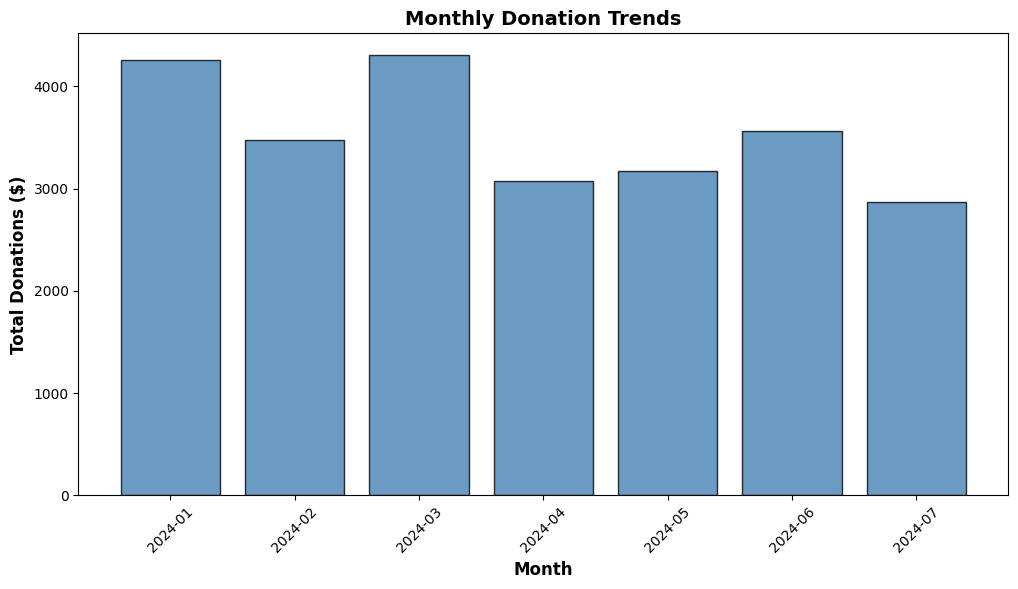

In [7]:
# # Create sample donation data for demonstration
# np.random.seed(42)
# dates = pd.date_range('2024-01-01', periods=100, freq='2D')
# sample_donations = pd.DataFrame({
#     'date': dates,
#     'donor_id': np.random.randint(100, 150, 100),
#     'amount': np.random.uniform(10, 500, 100),
#     'category': np.random.choice(['One-time', 'Recurring'], 100),
# })

# sample_donations.to_csv('donations.csv', index=False)

# Define the PIPELINE
def run_donation_analysis_pipeline(filepath):
    """
    Automated pipeline: Raw Data → Clean → Analyze → Report
    
    This replaces manual steps that took 2+ hours before!
    """
    print("🔄 Starting Donation Analysis Pipeline")
    print("="*50)
    
    # Step 1: Load & clean
    print("\n[1/4] Loading and cleaning data...")
    df = load_donation_data(filepath)
    print(f"  ✓ Loaded {len(df)} valid donation records")
    
    # Step 2: Calculate metrics
    print("\n[2/4] Calculating impact metrics...")
    metrics = calculate_impact_metrics(df)
    for key, value in metrics.items():
        print(f"  ✓ {key}: {value}")
    
    # Step 3: Identify loyal donors
    print("\n[3/4] Identifying repeat donors...")
    loyal = identify_loyal_donors(df, min_donations=2)
    print(f"  ✓ Found {len(loyal)} donors who gave 2+ times")
    
    # Step 4: Generate visualization
    print("\n[4/4] Creating trend visualization...")
    fig = plot_donation_trends(df)
    print("  ✓ Visualization generated")
    
    print("\n" + "="*50)
    print("✅ Pipeline Complete!")
    print("⏱️  Automation saved 2 hours of manual work")
    
    return df, metrics, loyal, fig

# Run the pipeline
df_result, metrics_result, loyal_result, fig_result = run_donation_analysis_pipeline('donations.csv')

## Part 3: Turn It Into a Streamlit App

Save this code as `donation_app.py` and run: `streamlit run donation_app.py`

In [ ]:
# Example Streamlit App Code
streamlit_app_code = '''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# Include functions from Part 1 here...
# (copy all the function definitions)

st.set_page_config(page_title="NGO Donation Dashboard", layout="wide")

st.title("🤝 Donation Impact Dashboard")
st.write("Automated analysis for NGO donation data")

# Sidebar for file upload
st.sidebar.header("📁 Upload Data")
uploaded_file = st.sidebar.file_uploader("Upload donation CSV", type=['csv'])

if uploaded_file is not None:
    # Run the pipeline
    df = load_donation_data(uploaded_file)
    metrics = calculate_impact_metrics(df)
    
    # Display impact metrics in a nice way
    st.subheader("📊 Impact Summary")
    col1, col2, col3 = st.columns(3)
    
    with col1:
        st.metric("Total Donated", metrics['Total Donated'])
    with col2:
        st.metric("Unique Donors", metrics['Unique Donors'])
    with col3:
        st.metric("Meals Served", metrics['Meals Served'])
    
    # Show data table
    st.subheader("💾 Donation Records")
    st.dataframe(df, use_container_width=True)
    
    # Show visualization
    st.subheader("📈 Donation Trends")
    fig = plot_donation_trends(df)
    st.pyplot(fig)
    
    # Show repeat donors
    st.subheader("⭐ Loyal Donors (2+ gifts)")
    loyal = identify_loyal_donors(df, min_donations=2)
    st.bar_chart(loyal)
    
    # Download processed data
    csv = df.to_csv(index=False)
    st.download_button(
        label="📥 Download Cleaned Data",
        data=csv,
        file_name="donations_processed.csv",
        mime="text/csv"
    )
    
else:
    st.info("👈 Upload a CSV file to get started!")
    st.write("\\nExpected columns: date, donor_id, amount, category, recurring")
'''

print("📱 STREAMLIT APP CODE")
print("="*60)
print(streamlit_app_code)
print("="*60)
print("\n🚀 To run this app:")
print("1. Save the code above as 'donation_app.py'")
print("2. Include all the functions from Part 1")
print("3. Run: streamlit run donation_app.py")
print("4. Open browser to http://localhost:8501")

## Why This Matters for Social Good Organizations

### Before Automation ❌
- Manual data entry and cleaning: 30 minutes
- Calculating metrics in Excel: 45 minutes
- Creating visualizations: 30 minutes
- Writing donor reports: 20 minutes
- **Total: ~2 hours per month**
- **Error rate: High** (manual calculations)
- **Staff frustration: High** (repetitive work)

### After Automation ✅
- Upload CSV file
- Dashboard generates instantly: **30 seconds**
- All calculations automated and consistent
- Professional reports generated automatically
- Staff time freed up for: Strategy, outreach, impact work
- **Error rate: Near zero** (code-based)
- **Scalability: Easy** (add more data, same pipeline)

### Real Impact
- **2 hours/month saved** → **24 hours/year**
- One staff member per org does this work
- That's **~1 week of freed-up time per year** per organization
- **1000+ NGOs doing this** = **1000+ weeks of staff time redirected to mission work**

### Key Takeaway
Data automation isn't fancy - it's **liberating**. It frees teams from tedious tasks to focus on the mission.

---

## Summary: Functions + Pipelines + Streamlit

| Component | Purpose | Example |
|-----------|---------|---------|
| **Functions** | Reusable logic | `load_donation_data()`, `calculate_impact_metrics()` |
| **Pipeline** | Workflow automation | Chain functions in sequence (Load → Clean → Analyze) |
| **Streamlit** | User interface | Non-technical staff can upload data and get results |